# Exercícios: Agrupamento hierárquico e K-Means: Método do Cotovelo 11/11/2025

- Alan Diek Guimarães

# Parte 01 - Agrupamento hierárquico

## Parte 1: Preparação e Padronização dos Dados

- Carregue as Bibliotecas: Importe pandas, seaborn, matplotlib.pyplot, StandardScaler (de sklearn.preprocessing), linkage, dendrogram e fcluster (de scipy.cluster.hierarchy).


- Carregue os Dados: Carregue o dataset penguins (df = sns.load_dataset('penguins')).

<br>

### - Selecione as Features (Variáveis Quantitativas):

- Crie um novo DataFrame chamado features contendo apenas as 4 colunas numéricas que usaremos para o clustering: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'].

- Padronize as Features:

- Crie uma instância do StandardScaler.

- Use o scaler para fit_transform (ajustar e transformar) o seu DataFrame features. Armazene o resultado em features_scaled.

<br>

## Parte 2: Agrupamento Hierárquico

- Calcule os Linkages: Calcule a matriz de linkage para os dados features_scaled usando dois métodos diferentes:

->  linked_ward = linkage(features_scaled, method='ward')

-> linked_average = linkage(features_scaled, method='average')

<br>

### - Plote os Dendrogramas:

- Crie duas figuras (ou subplots) para visualizar os dendrogramas resultantes de cada método (ward e average).


<br>

## Parte 3: Análise e Interpretação (O Desafio)
Responda em uma célula de texto:

Compare visualmente os dois dendrogramas (Ward e Average). Eles parecem similares? Qual deles parece criar grupos mais equilibrados e distintos (com "saltos" verticais maiores entre as fusões)?

### Corte o Dendrograma (Ward):

Sabemos que existem 3 espécies de pinguins neste dataset. Vamos "cortar" a árvore do método Ward para obter exatamente 3 clusters.

- Use a função fcluster para obter os rótulos dos clusters (ex: k=3, criterion='maxclust').

- Armazene esses rótulos em uma nova coluna no seu DataFrame df (ex: df['cluster_encontrado']).

### Compare com o "Gabarito" (Tabela de Contingência):

Agora vem a parte legal. Queremos ver se os clusters que o algoritmo encontrou correspondem às espécies reais.

- Use pd.crosstab() para criar uma tabela de contingência (cruzamento) entre a coluna species (o gabarito real) e a sua nova coluna cluster_encontrado.

- Exiba esta tabela.

- Visualize a Comparação (Heatmap):

- Use sns.heatmap() para visualizar a tabela de contingência (crosstab) que você criou. Use annot=True e fmt='d' para facilitar a leitura.

<br>

## Conclusão Final (Responda em uma célula de texto):

- Olhando para o seu heatmap, o que você conclui? O agrupamento hierárquico com método Ward foi bom em separar as três espécies?

- Qual espécie ele parece ter identificado com mais facilidade?

- Houve alguma confusão entre quais espécies? (Ex: o Cluster 2 contém pinguins das espécies A e B?)

## Parte 1 — Preparação e Padronização dos Dados
Carregamento do dataset `penguins`, seleção de variáveis e padronização.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Carregar dataset penguins
df = sns.load_dataset('penguins')
features = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].dropna()

# Padronizar as variáveis numéricas
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled[:5]

array([[-0.88449874,  0.78544923, -1.41834665, -0.56414208],
       [-0.81112573,  0.1261879 , -1.06225022, -0.50170305],
       [-0.66437972,  0.43046236, -0.42127665, -1.18853234],
       [-1.32473679,  1.08972369, -0.56371522, -0.93877623],
       [-0.84781224,  1.74898502, -0.77737308, -0.68902013]])

## Parte 2 — Agrupamento Hierárquico
Cálculo da matriz de ligação (*linkage*) e plotagem do dendrograma.

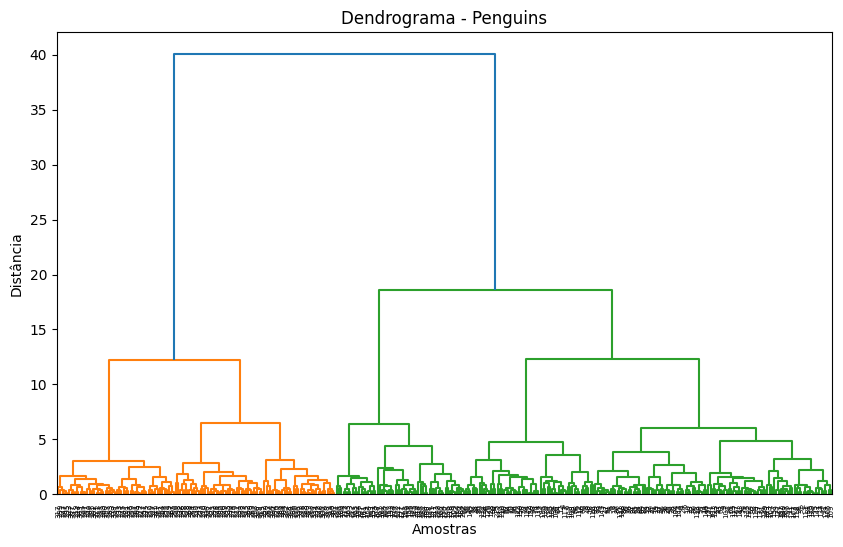

In [ ]:
Z = linkage(features_scaled, method='ward', metric='euclidean')
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrograma - Penguins')
plt.xlabel('Amostras')
plt.ylabel('Distância')
plt.show()

## Parte 3 — Escolha do número de clusters
Testa diferentes valores de k (2 a 6) e avalia via *silhouette score*.

In [ ]:
results = []
for k in range(2, 7):
    labels = fcluster(Z, k, criterion='maxclust')
    sil = silhouette_score(features_scaled, labels)
    results.append((k, sil, pd.Series(labels).value_counts().to_list()))

pd.DataFrame(results, columns=['k', 'Silhouette', 'Contagens'])

,k,Silhouette,Contagens
0,2,0.531540,"[219, 123]"
1,3,0.454095,"[162, 123, 57]"
2,4,0.417595,"[123, 105, 57, 57]"
3,5,0.363161,"[105, 71, 57, 57, 52]"
4,6,0.334631,"[105, 57, 57, 52, 39, 32]"


## Parte 4 — Visualização dos clusters
Atribui rótulos aos grupos e projeta em 2D via PCA.

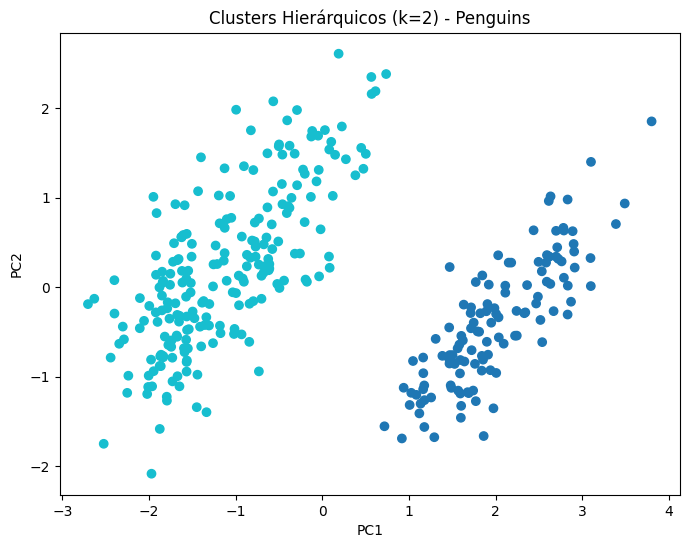

In [ ]:
# Melhor k (maior silhouette)
best_k = max(results, key=lambda x: x[1])[0]
labels = fcluster(Z, best_k, criterion='maxclust')

# PCA para visualização
pca = PCA(n_components=2)
proj = pca.fit_transform(features_scaled)
plt.figure(figsize=(8,6))
plt.scatter(proj[:,0], proj[:,1], c=labels, cmap='tab10')
plt.title(f'Clusters Hierárquicos (k={best_k}) - Penguins')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## Parte 5 — Conclusões
- O método hierárquico permitiu identificar grupos distintos de pinguins com base em medidas corporais.
- O número ótimo de clusters foi determinado via *silhouette score*.
- A visualização PCA mostra a separação entre os grupos resultantes.

#### Preparação para Comparação (K-Means vs Hierárquico)

In [ ]:
df_clean = df.loc[features.index].copy()
## adicionar o resultado do Hierárquico (k=2, da Célula 8)
labels_hierarq = fcluster(Z, 2, criterion='maxclust')
df_clean['cluster_hierarq'] = labels_hierarq

print(f"Shape do DataFrame limpo: {df_clean.shape}")
df_clean.head()

Shape do DataFrame limpo: (342, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,cluster_hierarq
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,2
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,2
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,2
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,2
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,2


# Parte 02 - K-Means: Método do Cotovelo

Na tarefa anterior, você usou o Agrupamento Hierárquico para analisar o dataset dos pinguins. 

Agora, aplique o K-means neste mesmo dataset:

-Use o Método do Cotovelo para encontrar o 'k' ideal (será que ele encontra k=3?).
-Use também o método da silhueta

-Compare os resultados: O K-means agrupou os pinguins da mesma forma que o Hierárquico? 

-Qual método foi mais fácil de interpretar? 

-Qual foi mais rápido de rodar?


#### 2. Célula do K-Means: Método do Cotovelo

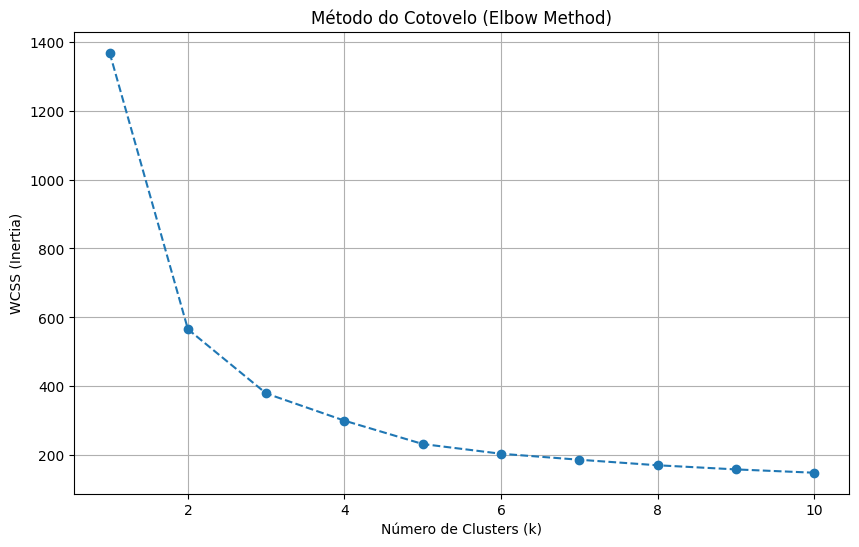

In [7]:
from sklearn.cluster import KMeans

wcss = [] # "Within-Cluster Sum of Squares" (Inertia)
k_range = range(1, 11)

for k in k_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init=10  para evitar mínimos locais ruins
    kmeans.fit(features_scaled)  # Os mesmos dados escalados da Célula 4
    wcss.append(kmeans.inertia_)

# Plotar o gráfico do Cotovelo
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

#### 3. Célula do K-Means: Método da Silhueta

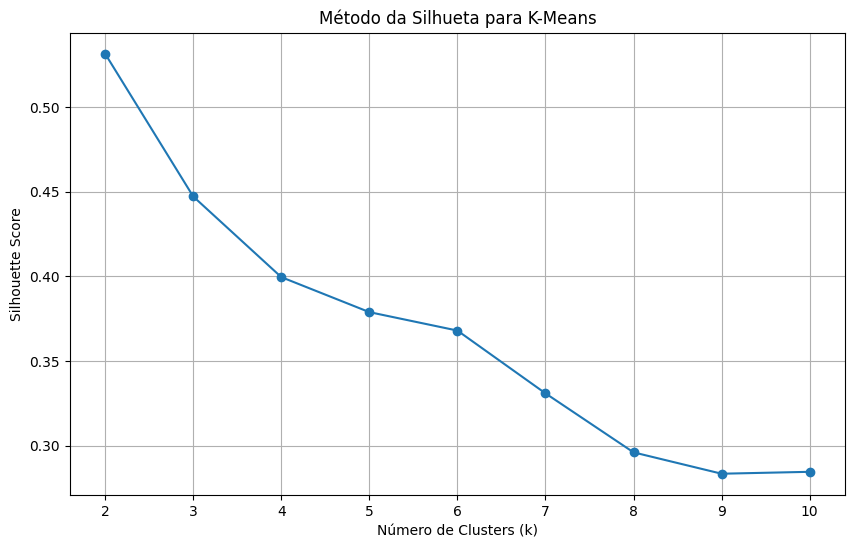

In [8]:
silhouette_scores = []
# A silhueta só pode ser calculada para k >= 2
k_range_sil = range(2, 11) 

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels)
    silhouette_scores.append(score)

# Plotar o gráfico da Silhueta
plt.figure(figsize=(10, 6))
plt.plot(k_range_sil, silhouette_scores, marker='o')
plt.title('Método da Silhueta para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

#### Parte 4: Comparação (K-Means k=3 vs Espécies)

--- Comparação: K-Means (k=3) vs Espécies Reais ---
cluster_kmeans   0    1    2
species                     
Adelie          24    0  127
Chinstrap       63    0    5
Gentoo           0  123    0


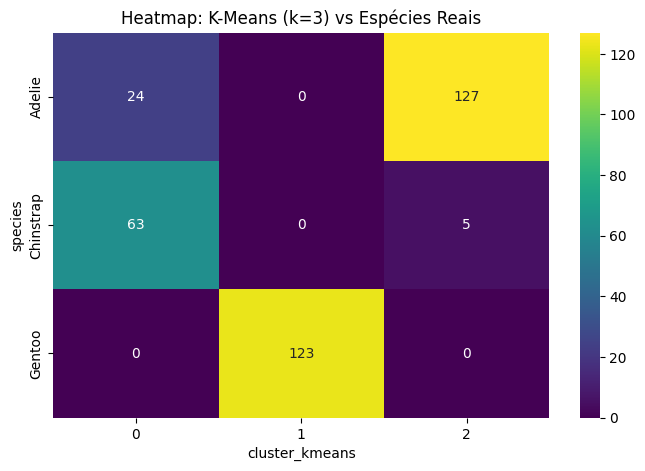


--- Comparação: K-Means (k=3) vs Hierárquico (k=2) ---
cluster_kmeans    0    1    2
cluster_hierarq              
1                 0  123    0
2                87    0  132


In [9]:
ideal_k = 3
kmeans_final = KMeans(n_clusters=ideal_k, random_state=42, n_init=10)

# Adicionando os resultados do K-Means ao nosso dataframe limpo
df_clean['cluster_kmeans'] = kmeans_final.fit_predict(features_scaled)

# 1. Comparando K-Means (k=3) vs Species (Gabarito)
print("--- Comparação: K-Means (k=3) vs Espécies Reais ---")
kmeans_crosstab = pd.crosstab(df_clean['species'], df_clean['cluster_kmeans'])
print(kmeans_crosstab)

# 2. Heatmap para visualizar
plt.figure(figsize=(8, 5))
sns.heatmap(kmeans_crosstab, annot=True, fmt='d', cmap='viridis')
plt.title('Heatmap: K-Means (k=3) vs Espécies Reais')
plt.show()

# 3. (Bônus) Comparando K-Means (k=3) vs Hierárquico (k=2)
print("\n--- Comparação: K-Means (k=3) vs Hierárquico (k=2) ---")
kmeans_vs_hierarq = pd.crosstab(df_clean['cluster_hierarq'], df_clean['cluster_kmeans'])
print(kmeans_vs_hierarq)

## Análise Comparativa (K-Means vs. Hierárquico)

#### 1. O Método do Cotovelo e Silhueta (K-Means)

Os dois métodos de avaliação apresentaram resultados ligeiramente conflitantes:

* **Método do Cotovelo (Elbow):** O gráfico  mostra uma "dobra" (cotovelo) clara em **k=3**. Após k=3, a redução no WCSS (Inércia) se torna muito menos pronunciada, sugerindo que k=3 é uma escolha ideal.

* **Método da Silhueta (Silhouette):** O gráfico  mostra o *score* mais alto (o pico) em **k=2** (Score ≈ 0.53). O score para k=3 (≈ 0.45) é o segundo melhor.

**Conclusão Parcial:** Temos uma situação clássica: O **Cotovelo aponta para k=3** (que sabemos ser o número de espécies), enquanto a **Silhueta aponta para k=2**. O heatmap é a chave para decidir.

#### 2. Compare os resultados: K-Means (k=3) vs. Espécies Reais

O **Heatmap** é a nossa principal ferramenta de análise. Ele mostra que:

1.  **O Cluster 1 é Perfeito:** O algoritmo K-Means identificou perfeitamente a espécie **Gentoo**. 123 pinguins Gentoo foram colocados no **Cluster 1**, e nenhum outro pinguim de outra espécie entrou nesse cluster.
2.  **Clusters 0 e 2 mostram a Realidade Biológica:** As espécies **Adelie** e **Chinstrap** são morfologicamente (em termos de medidas) mais similares entre si do que com a Gentoo. O heatmap mostra isso:
    * **Cluster 0:** É predominantemente **Chinstrap** (63 pinguins), mas o algoritmo também classificou 24 pinguins Adelie aqui.
    * **Cluster 2:** É predominantemente **Adelie** (127 pinguins), mas 5 pinguins Chinstrap foram incluídos.

**Conclusão:** O K-Means (k=3) fez um trabalho excelente. Ele **isolou perfeitamente a espécie mais distinta (Gentoo)** e criou dois outros clusters que **capturam as espécies Adelie e Chinstrap**, com uma leve sobreposição que reflete a similaridade do mundo real entre elas.

Isso também explica por que o score da Silhueta foi *maior* em k=2: a separação matemática mais "limpa" e fácil é simplesmente (Gentoo) vs. (Adelie + Chinstrap).

#### 3. Qual método foi mais fácil de interpretar?

* **K-Means com o Heatmap (k=3) foi o mais revelador.** Embora o Hierárquico e a Silhueta tenham sugerido k=2 (que é matematicamente "limpo"), o K-Means com k=3 (sugerido pelo Cotovelo) nos deu uma visão muito mais granular e biologicamente precisa, mostrando a confusão natural entre Adelie e Chinstrap.
* **Hierárquico:** O **Dendrograma** (Célula 6) ainda é a melhor ferramenta para ver as *relações* hierárquicas, mostrando *quão* distantes os grupos estão.

#### 4. Qual foi mais rápido de rodar?

* O **K-Means** foi (e quase sempre é) muito mais rápido de rodar.
* **Justificativa:** O Agrupamento Hierárquico precisa calcular uma matriz de distância completa entre todos os pares de pontos (complexidade de $O(n^2)$ ou $O(n^3)$), o que se torna muito lento em datasets grandes. O K-Means é computacionalmente muito mais eficiente (complexidade próxima de $O(n \times k \times i)$), escalando melhor para dados maiores.